In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e3/train.csv
/kaggle/input/competitions/playground-series-s6e3/test.csv


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# ── Load Data ─────────────────────────────────────────
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')
sub   = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv')

# ── Fix Target FIRST ──────────────────────────────────
# Handles both 'Yes'/'No' strings AND already 0/1 integers
if train['Churn'].dtype == object:
    train['Churn'] = train['Churn'].map({'Yes': 1, 'No': 0})

train['Churn'] = train['Churn'].astype(int)

print(f'Train : {train.shape}')
print(f'Test  : {test.shape}')
print(f'\nChurn dtype  : {train["Churn"].dtype}')
print(f'Churn values : {train["Churn"].unique()}')
print(f'\nTarget distribution:\n{train["Churn"].value_counts(normalize=True).round(3)}')
print(f'\nColumn dtypes:\n{train.dtypes}')
train.head()

Train : (594194, 21)
Test  : (254655, 20)

Churn dtype  : int64
Churn values : [0 1]

Target distribution:
Churn
0    0.775
1    0.225
Name: proportion, dtype: float64

Column dtypes:
id                    int64
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1


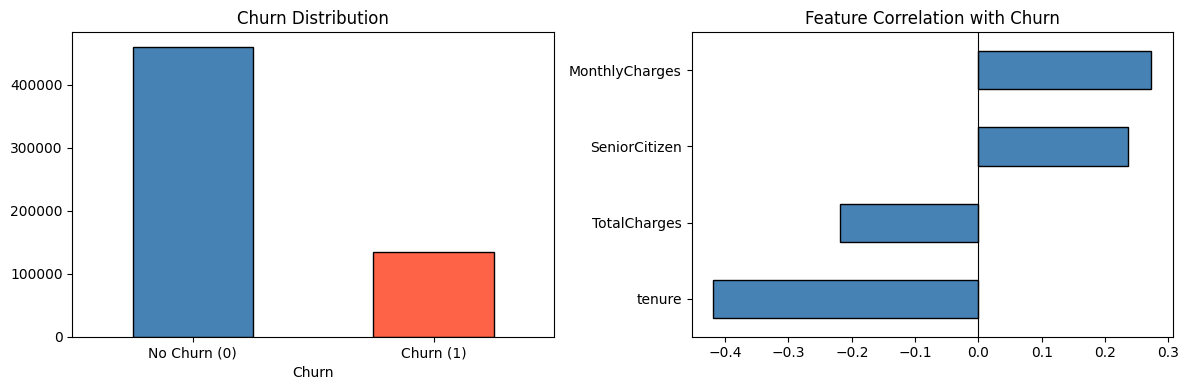


Top 5 positive correlations:
tenure           -0.418453
TotalCharges     -0.218365
SeniorCitizen     0.236362
MonthlyCharges    0.272997
Name: Churn, dtype: float64

Top 5 negative correlations:
tenure           -0.418453
TotalCharges     -0.218365
SeniorCitizen     0.236362
MonthlyCharges    0.272997
Name: Churn, dtype: float64

Total numeric features: 4


In [9]:
# ── EDA ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Target balance
train['Churn'].value_counts().plot(kind='bar', ax=axes[0],
    color=['steelblue','tomato'], edgecolor='black')
axes[0].set_title('Churn Distribution')
axes[0].set_xticklabels(['No Churn (0)', 'Churn (1)'], rotation=0)

# Safe numeric correlation — force convert everything first
train_num = train.copy()
for col in train_num.columns:
    train_num[col] = pd.to_numeric(train_num[col], errors='coerce')

num_cols = [c for c in train_num.columns if c not in ['id', 'Churn']]
num_cols = [c for c in num_cols if train_num[c].notna().sum() > 0]

corr = train_num[num_cols + ['Churn']].corr()['Churn'].drop('Churn').sort_values()
corr.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Feature Correlation with Churn')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

print(f'\nTop 5 positive correlations:\n{corr.tail(5)}')
print(f'\nTop 5 negative correlations:\n{corr.head(5)}')
print(f'\nTotal numeric features: {len(num_cols)}')

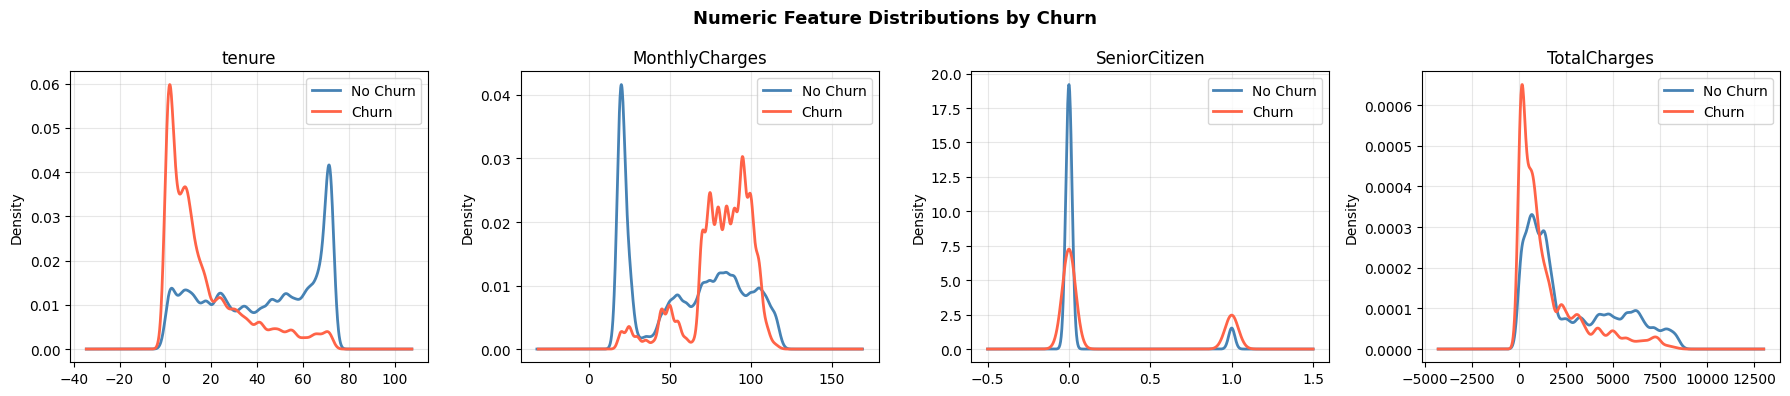

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


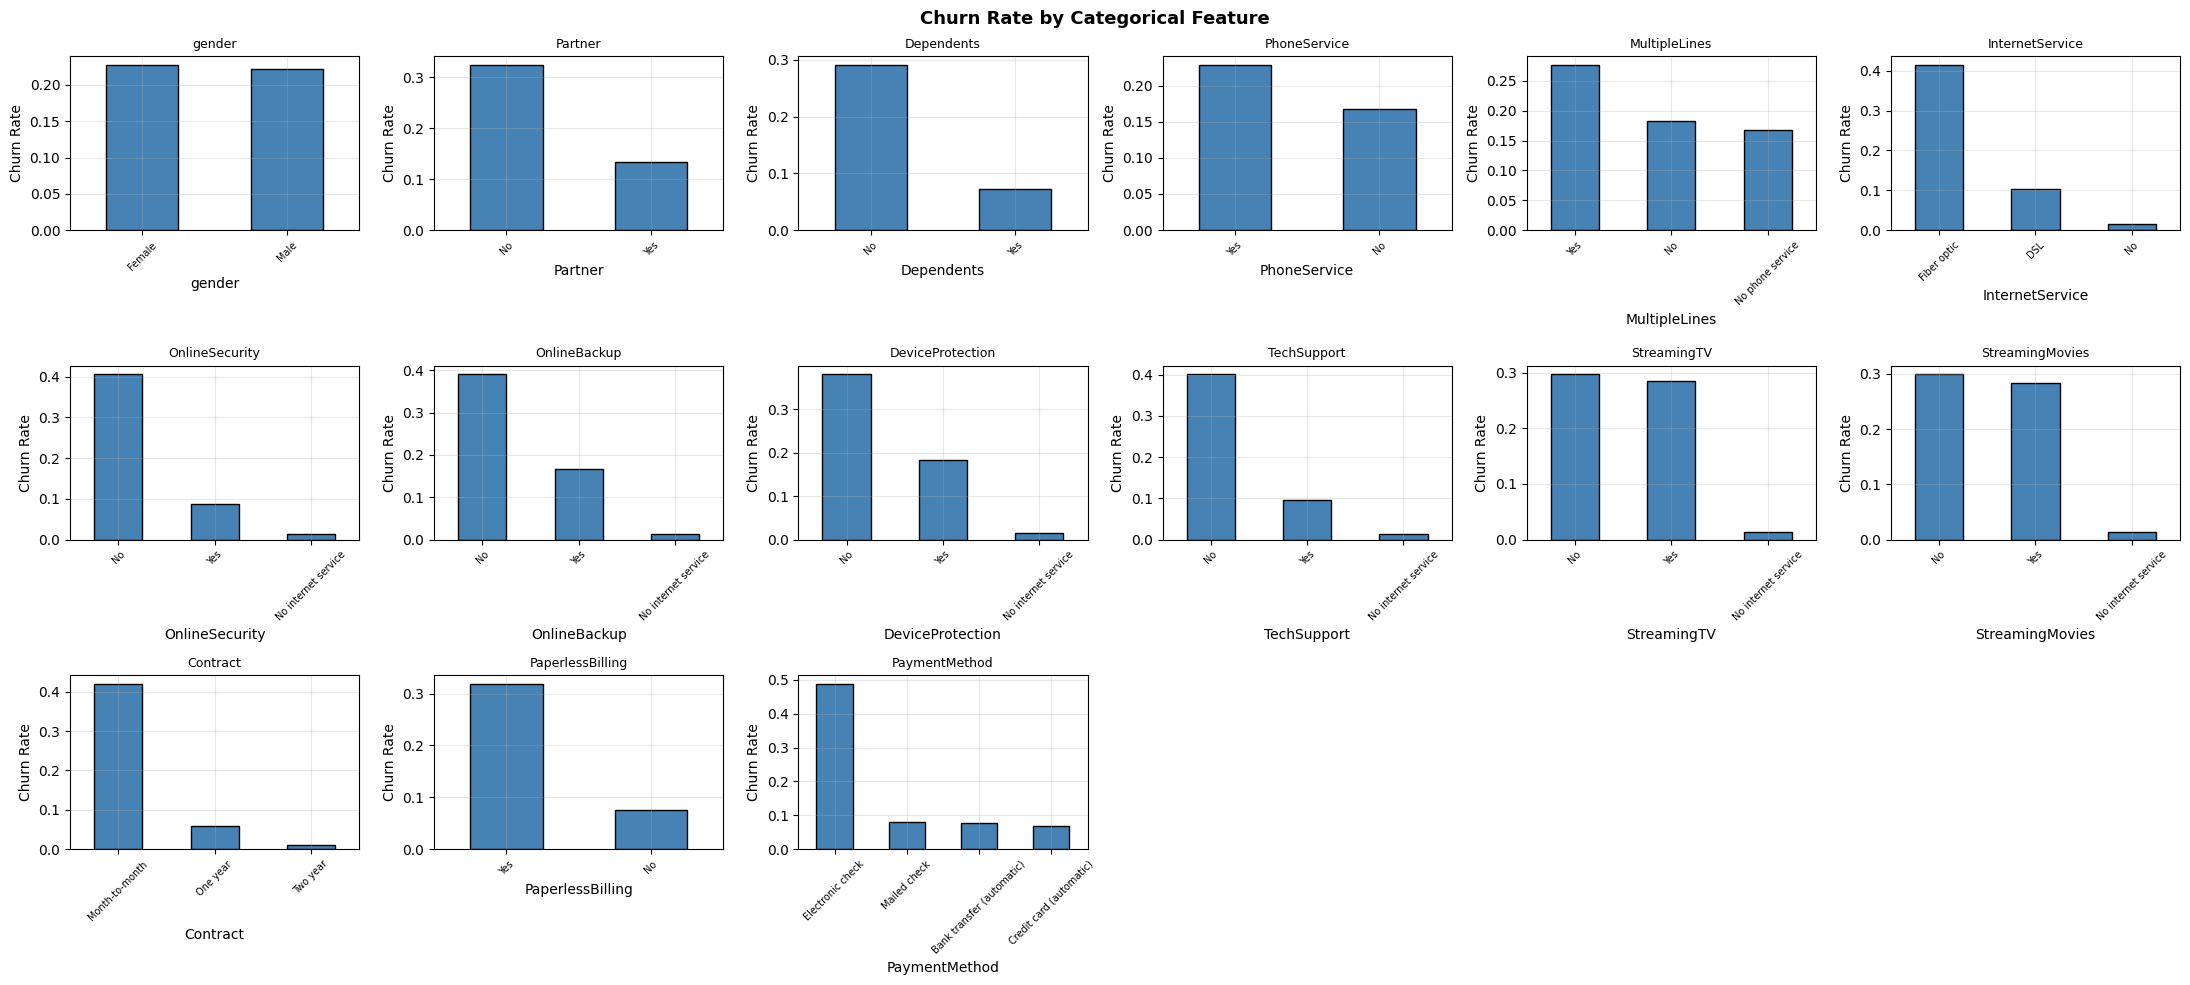

In [10]:
# ── Feature Distributions by Churn ────────────────────
top_features = corr.abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes.flatten(), top_features):
    for churn_val, label, color in [(0,'No Churn','steelblue'), (1,'Churn','tomato')]:
        train[train['Churn'] == churn_val][col].dropna().plot(
            kind='kde', ax=ax, label=label, color=color, linewidth=2)
    ax.set_title(col)
    ax.legend()
    ax.grid(alpha=0.3)
plt.suptitle('Numeric Feature Distributions by Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Categorical Feature vs Churn ──────────────────────
cat_cols_raw = train.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns: {cat_cols_raw}')

fig, axes = plt.subplots(3, 6, figsize=(22, 10))
for ax, col in zip(axes.flatten(), cat_cols_raw):
    churn_rate = train.groupby(col)['Churn'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(col, fontsize=9)
    ax.set_ylabel('Churn Rate')
    ax.tick_params(axis='x', labelsize=7, rotation=45)
    ax.grid(alpha=0.3)
for ax in axes.flatten()[len(cat_cols_raw):]:
    ax.set_visible(False)
plt.suptitle('Churn Rate by Categorical Feature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# ── Feature Engineering ───────────────────────────────
def feature_engineering(df):
    df = df.copy()

    # ── Encode all string columns ──────────────────────
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    for col in cat_cols:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

    # ── Force convert hidden string numerics ──────────
    for col in df.columns:
        if col in ['id', 'Churn']:
            continue
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # ── Fill NaNs ──────────────────────────────────────
    df = df.fillna(df.median(numeric_only=True))

    # ── Numeric cols list ─────────────────────────────
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    num_cols = [c for c in num_cols if c not in ['id', 'Churn']]

    # ── Interaction features ───────────────────────────
    if 'tenure' in df.columns and 'MonthlyCharges' in df.columns:
        df['charge_per_tenure']  = df['MonthlyCharges'] / (df['tenure'] + 1)
        df['total_charge_est']   = df['MonthlyCharges'] * df['tenure']
        df['tenure_x_monthly']   = df['tenure'] * df['MonthlyCharges']

    if 'TotalCharges' in df.columns and 'MonthlyCharges' in df.columns:
        df['charge_ratio']       = df['TotalCharges'] / (df['MonthlyCharges'] + 1)
        df['charges_diff']       = df['TotalCharges'] - df['total_charge_est'] \
                                   if 'total_charge_est' in df.columns \
                                   else df['TotalCharges'] - df['MonthlyCharges']

    if 'tenure' in df.columns:
        df['tenure_squared']     = df['tenure'] ** 2
        df['tenure_log']         = np.log1p(df['tenure'])
        df['is_new_customer']    = (df['tenure'] <= 3).astype(int)
        df['is_long_customer']   = (df['tenure'] >= 48).astype(int)

    if 'MonthlyCharges' in df.columns:
        df['monthly_log']        = np.log1p(df['MonthlyCharges'])
        df['is_high_payer']      = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)

    if 'TotalCharges' in df.columns:
        df['total_log']          = np.log1p(df['TotalCharges'])

    # ── Count of services (if service cols exist) ─────
    service_cols = [c for c in df.columns if c in [
        'PhoneService','MultipleLines','InternetService',
        'OnlineSecurity','OnlineBackup','DeviceProtection',
        'TechSupport','StreamingTV','StreamingMovies'
    ]]
    if len(service_cols) > 0:
        df['num_services'] = df[service_cols].sum(axis=1)

    # ── Aggregate stats across all numeric features ───
    df['num_sum']  = df[num_cols].sum(axis=1)
    df['num_mean'] = df[num_cols].mean(axis=1)
    df['num_std']  = df[num_cols].std(axis=1)
    df['num_max']  = df[num_cols].max(axis=1)
    df['num_min']  = df[num_cols].min(axis=1)

    return df

train_fe = feature_engineering(train)
test_fe  = feature_engineering(test)

TARGET   = 'Churn'
DROP     = ['id', TARGET]
FEATURES = [c for c in train_fe.columns if c not in DROP]

X      = train_fe[FEATURES]
y      = train_fe[TARGET]
X_test = test_fe[FEATURES]

print(f'✅ Features after engineering : {len(FEATURES)}')
print(f'X      : {X.shape}')
print(f'y      : {y.shape}')
print(f'X_test : {X_test.shape}')
print(f'\nFeature list:\n{FEATURES}')

✅ Features after engineering : 37
X      : (594194, 37)
y      : (594194,)
X_test : (254655, 37)

Feature list:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'charge_per_tenure', 'total_charge_est', 'tenure_x_monthly', 'charge_ratio', 'charges_diff', 'tenure_squared', 'tenure_log', 'is_new_customer', 'is_long_customer', 'monthly_log', 'is_high_payer', 'total_log', 'num_services', 'num_sum', 'num_mean', 'num_std', 'num_max', 'num_min']


In [12]:
xgb_params = dict(
    n_estimators          = 2000,
    learning_rate         = 0.03,
    max_depth             = 6,
    min_child_weight      = 5,
    gamma                 = 0.1,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    scale_pos_weight      = (y==0).sum() / (y==1).sum(),
    tree_method           = 'hist',
    device                = 'cuda',   # ← P100 activated
    eval_metric           = 'auc',
    early_stopping_rounds = 100,
    random_state          = SEED,
    n_jobs                = -1
)

cat_params = dict(
    iterations         = 2000,
    learning_rate      = 0.03,
    depth              = 6,
    l2_leaf_reg        = 3,
    subsample          = 0.8,
    colsample_bylevel  = 0.8,
    min_data_in_leaf   = 20,
    auto_class_weights = 'Balanced',
    eval_metric        = 'AUC',
    task_type          = 'GPU',       # ← P100 activated
    random_seed        = SEED,
    verbose            = False
)

In [13]:
from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb

N_SPLITS = 10
SEED     = 42
skf      = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_xgb  = np.zeros(len(X))
oof_lgb  = np.zeros(len(X))
oof_cat  = np.zeros(len(X))
pred_xgb = np.zeros(len(X_test))
pred_lgb = np.zeros(len(X_test))
pred_cat = np.zeros(len(X_test))

In [14]:
# ── XGBoost ───────────────────────────────────────────
print('='*50)
print('🚀 Training XGBoost...')
print('='*50)

xgb_params = dict(
    n_estimators          = 2000,
    learning_rate         = 0.03,
    max_depth             = 6,
    min_child_weight      = 5,
    gamma                 = 0.1,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    scale_pos_weight      = (y==0).sum() / (y==1).sum(),
    tree_method           = 'hist',
    eval_metric           = 'auc',
    early_stopping_rounds = 100,
    random_state          = SEED,
    n_jobs                = -1
)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = XGBClassifier(**xgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set = [(X_val, y_val)],
        verbose  = False
    )

    oof_xgb[val_idx]  = model.predict_proba(X_val)[:, 1]
    pred_xgb         += model.predict_proba(X_test)[:, 1] / N_SPLITS
    print(f'  Fold {fold+1:2d} | AUC: {roc_auc_score(y_val, oof_xgb[val_idx]):.5f}')

print(f'\n📊 XGBoost OOF AUC: {roc_auc_score(y, oof_xgb):.5f}')

🚀 Training XGBoost...
  Fold  1 | AUC: 0.91654
  Fold  2 | AUC: 0.91562
  Fold  3 | AUC: 0.91826
  Fold  4 | AUC: 0.91584
  Fold  5 | AUC: 0.91642
  Fold  6 | AUC: 0.91692
  Fold  7 | AUC: 0.91821
  Fold  8 | AUC: 0.91702
  Fold  9 | AUC: 0.91553
  Fold 10 | AUC: 0.91416

📊 XGBoost OOF AUC: 0.91644


In [15]:
# ── LightGBM ──────────────────────────────────────────
print('='*50)
print('🚀 Training LightGBM...')
print('='*50)

lgb_params = dict(
    n_estimators      = 2000,
    learning_rate     = 0.03,
    num_leaves        = 63,
    max_depth         = -1,
    min_child_samples = 20,
    feature_fraction  = 0.8,
    bagging_fraction  = 0.8,
    bagging_freq      = 5,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    is_unbalance      = True,
    random_state      = SEED,
    n_jobs            = -1,
    verbosity         = -1
)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = LGBMClassifier(**lgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set    = [(X_val, y_val)],
        eval_metric = 'auc',
        callbacks   = [
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(False)
        ]
    )

    oof_lgb[val_idx]  = model.predict_proba(X_val)[:, 1]
    pred_lgb         += model.predict_proba(X_test)[:, 1] / N_SPLITS
    print(f'  Fold {fold+1:2d} | AUC: {roc_auc_score(y_val, oof_lgb[val_idx]):.5f}')

🚀 Training LightGBM...
  Fold  1 | AUC: 0.91234
  Fold  2 | AUC: 0.91156
  Fold  3 | AUC: 0.91417
  Fold  4 | AUC: 0.91154
  Fold  5 | AUC: 0.91200
  Fold  6 | AUC: 0.91274
  Fold  7 | AUC: 0.91402
  Fold  8 | AUC: 0.91307
  Fold  9 | AUC: 0.91157
  Fold 10 | AUC: 0.91018


In [16]:
# ── CatBoost (Fixed for GPU) ──────────────────────────
print('='*50)
print('🚀 Training CatBoost...')
print('='*50)

cat_params = dict(
    iterations         = 2000,
    learning_rate      = 0.03,
    depth              = 6,
    l2_leaf_reg        = 3,
    bootstrap_type     = 'Bernoulli',
    subsample          = 0.8,
    # colsample_bylevel removed — not supported on GPU
    min_data_in_leaf   = 20,
    auto_class_weights = 'Balanced',
    eval_metric        = 'AUC',
    task_type          = 'GPU',
    random_seed        = SEED,
    verbose            = False
)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = CatBoostClassifier(**cat_params)
    model.fit(
        X_tr, y_tr,
        eval_set              = (X_val, y_val),
        early_stopping_rounds = 100
    )

    oof_cat[val_idx]  = model.predict_proba(X_val)[:, 1]
    pred_cat         += model.predict_proba(X_test)[:, 1] / N_SPLITS
    print(f'  Fold {fold+1:2d} | AUC: {roc_auc_score(y_val, oof_cat[val_idx]):.5f}')

print(f'\n📊 CatBoost OOF AUC: {roc_auc_score(y, oof_cat):.5f}')

# ── Summary ───────────────────────────────────────────
print('\n' + '='*50)
print('📊 GBDT Summary')
print('='*50)
print(f'  XGBoost  OOF AUC : {roc_auc_score(y, oof_xgb):.5f}')
print(f'  LightGBM OOF AUC : {roc_auc_score(y, oof_lgb):.5f}')
print(f'  CatBoost OOF AUC : {roc_auc_score(y, oof_cat):.5f}')

🚀 Training CatBoost...


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold  1 | AUC: 0.91592


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold  2 | AUC: 0.91572


...

  Fold  8 | AUC: 0.91692


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold  9 | AUC: 0.91556


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 10 | AUC: 0.91377

📊 CatBoost OOF AUC: 0.91622

📊 GBDT Summary
  XGBoost  OOF AUC : 0.91644
  LightGBM OOF AUC : 0.91224
  CatBoost OOF AUC : 0.91622


🔍 Running Optuna weight search (1000 trials)...


  0%|          | 0/1000 [00:00<?, ?it/s]


⚖️  Optimal weights:
  XGBoost     : 0.6332
  LightGBM    : 0.0000
  CatBoost    : 0.3668

📊 Weighted Blend OOF AUC : 0.91656

🚀 Training Level-2 Stacker...
📊 Level-2 Stack OOF AUC  : 0.91655

🏆 FINAL OOF AUC          : 0.91655


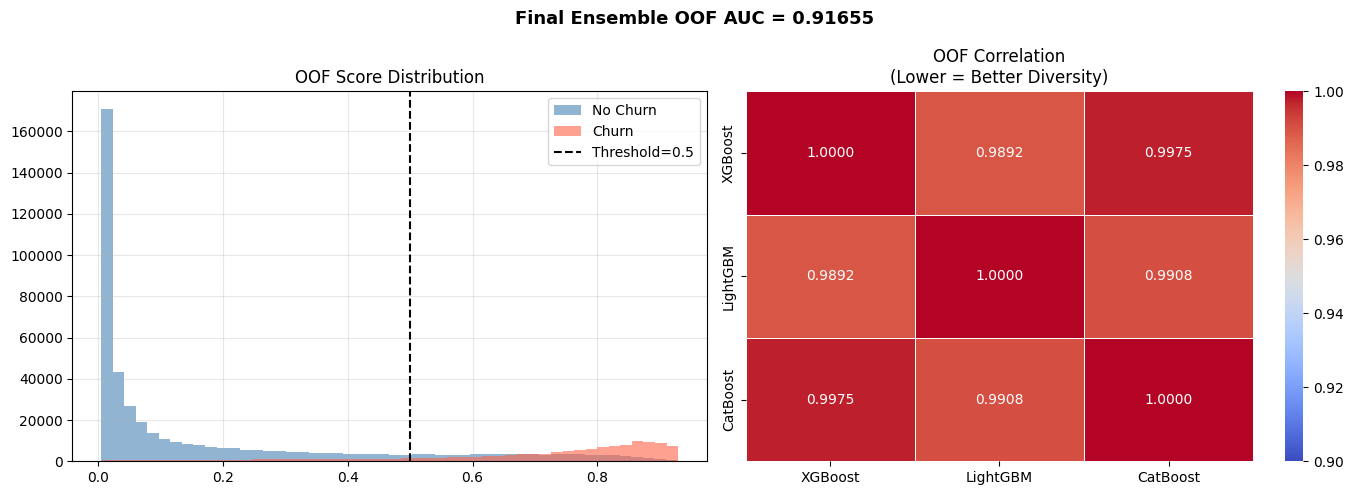


✅ submission.csv saved — 254655 rows
  Mean : 0.2917
  Std  : 0.3159
  Min  : 0.0055
  Max  : 0.9290

🏆 FINAL SUMMARY
  XGBoost  OOF AUC : 0.91644
  LightGBM OOF AUC : 0.91224
  CatBoost OOF AUC : 0.91622
  Blend    OOF AUC : 0.91656
  Stack    OOF AUC : 0.91655
  ─────────────────────────────
  FINAL    OOF AUC : 0.91655 🎯

✅ DONE — Output tab → submission.csv → Submit!


In [17]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.linear_model import LogisticRegression

# ── Stack OOFs ────────────────────────────────────────
names       = ['XGBoost', 'LightGBM', 'CatBoost']
oof_matrix  = np.column_stack([oof_xgb, oof_lgb, oof_cat])
pred_matrix = np.column_stack([pred_xgb, pred_lgb, pred_cat])

# ── Optuna Weight Search ──────────────────────────────
print('🔍 Running Optuna weight search (1000 trials)...')

def objective(trial):
    w = np.array([trial.suggest_float(f'w{i}', 0.0, 1.0) for i in range(3)])
    w = w / w.sum()
    return roc_auc_score(y, (oof_matrix * w).sum(axis=1))

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=1000, show_progress_bar=True)

best_w = np.array([study.best_params[f'w{i}'] for i in range(3)])
best_w = best_w / best_w.sum()

print(f'\n⚖️  Optimal weights:')
for n, w in zip(names, best_w):
    print(f'  {n:12s}: {w:.4f}')

oof_blend  = (oof_matrix  * best_w).sum(axis=1)
pred_blend = (pred_matrix * best_w).sum(axis=1)
print(f'\n📊 Weighted Blend OOF AUC : {roc_auc_score(y, oof_blend):.5f}')

# ── Level-2 Stacker ───────────────────────────────────
print('\n🚀 Training Level-2 Stacker...')

oof_stack  = np.zeros(len(y))
pred_stack = np.zeros(pred_xgb.shape[0])

for fold, (tr_idx, val_idx) in enumerate(skf.split(oof_matrix, y)):
    meta = LogisticRegression(C=1.0, max_iter=1000)
    meta.fit(oof_matrix[tr_idx], y.iloc[tr_idx])
    oof_stack[val_idx]  = meta.predict_proba(oof_matrix[val_idx])[:, 1]
    pred_stack         += meta.predict_proba(pred_matrix)[:, 1] / N_SPLITS

print(f'📊 Level-2 Stack OOF AUC  : {roc_auc_score(y, oof_stack):.5f}')

# ── Final Blend ───────────────────────────────────────
FINAL_W    = 0.6
oof_final  = FINAL_W * oof_blend  + (1 - FINAL_W) * oof_stack
pred_final = FINAL_W * pred_blend + (1 - FINAL_W) * pred_stack

print(f'\n🏆 FINAL OOF AUC          : {roc_auc_score(y, oof_final):.5f}')

# ── Visualize ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(oof_final[y==0], bins=50, alpha=0.6, label='No Churn', color='steelblue')
axes[0].hist(oof_final[y==1], bins=50, alpha=0.6, label='Churn',    color='tomato')
axes[0].axvline(0.5, color='black', linestyle='--', label='Threshold=0.5')
axes[0].set_title('OOF Score Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

oof_df = pd.DataFrame(oof_matrix, columns=names)
sns.heatmap(oof_df.corr(), annot=True, fmt='.4f', cmap='coolwarm',
            vmin=0.9, vmax=1.0, ax=axes[1], linewidths=0.5)
axes[1].set_title('OOF Correlation\n(Lower = Better Diversity)')

plt.suptitle(f'Final Ensemble OOF AUC = {roc_auc_score(y, oof_final):.5f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Generate Submission ───────────────────────────────
sub['Churn'] = pred_final
sub.to_csv('submission.csv', index=False)

print(f'\n✅ submission.csv saved — {len(sub)} rows')
print(f'  Mean : {pred_final.mean():.4f}')
print(f'  Std  : {pred_final.std():.4f}')
print(f'  Min  : {pred_final.min():.4f}')
print(f'  Max  : {pred_final.max():.4f}')

# ── Final Summary ─────────────────────────────────────
print('\n' + '='*50)
print('🏆 FINAL SUMMARY')
print('='*50)
print(f'  XGBoost  OOF AUC : {roc_auc_score(y, oof_xgb):.5f}')
print(f'  LightGBM OOF AUC : {roc_auc_score(y, oof_lgb):.5f}')
print(f'  CatBoost OOF AUC : {roc_auc_score(y, oof_cat):.5f}')
print(f'  Blend    OOF AUC : {roc_auc_score(y, oof_blend):.5f}')
print(f'  Stack    OOF AUC : {roc_auc_score(y, oof_stack):.5f}')
print(f'  ─────────────────────────────')
print(f'  FINAL    OOF AUC : {roc_auc_score(y, oof_final):.5f} 🎯')
print('='*50)
print('\n✅ DONE — Output tab → submission.csv → Submit!')